In [18]:
# Lab 3 – Model Explainability using SHAP and LIME

# This notebook trains a supervised and a semi-supervised
# logistic regression model and evaluates their predictions
# using SHAP and LIME explanations.

In [19]:

# Step 1: Load, clean, split, and scale the dataset

# Remove leading/trailing whitespace from column names.
# Replace infinite values with NaN and remove rows containing missing values.
# Duplicate rows are also removed before training.

# The target variable is converted into a binary classification:
# 0 = BENIGN traffic
# 1 = Attack traffic

# The dataset is split into training, validation, and test sets.
# StandardScaler is fitted only on the training data and then
# applied to the training, validation, and test sets.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

SEED = 42
print("Ready. Seed:", SEED)

Ready. Seed: 42


In [20]:
# STep 1: Train the supervised and semi-supervised models

# The supervised model is trained using all available training labels.

# For the semi-supervised model, only 5% of the training data
# is initially treated as labelled. The remaining 95% is used
# as an unlabelled pool for pseudo-labelling.

# The pseudo-labelling process selects predictions with a confidence
# of at least 99%, adds them to the labelled training set, and
# retrains the model for several rounds.
file = "c:\\Users\\alexa\\Downloads\\D7084E Cyber AI\\D7084_Lab3\\MachineLearningCVE\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(file)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

X = df.drop(columns=["Label"])
y = (df["Label"] != "BENIGN").astype(int)

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

feature_names = list(X.columns)

print("Data ready.")
print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Data ready.
Train: (133849, 78)  Test: (44617, 78)


In [21]:
# Step 1:Import SHAP and LIME

# SHAP and LIME are used to explain the predictions made by
# the supervised and semi-supervised models.

# Supervised model (Lab 1): trained on ALL training labels
lr_full = LogisticRegression(C=100, max_iter=1000, random_state=SEED)
lr_full.fit(X_train_scaled, y_train)
print("Supervised model trained.")

# Semi-supervised model (Lab 2): pseudo-labelling at 5% labels
X_lab_5, X_unlab_5, y_lab_5, y_unlab_5 = train_test_split(
    X_train_scaled, y_train, train_size=0.05, stratify=y_train, random_state=SEED)

def pseudo_label(X_labelled, y_labelled, X_pool, y_pool, cutoff, rounds, batch):
    X_now = X_labelled
    y_now = np.array(y_labelled)
    X_left = X_pool
    y_left = np.array(y_pool)
    model = LogisticRegression(C=100, max_iter=1000, random_state=SEED).fit(X_now, y_now)
    for r in range(rounds):
        if len(X_left) == 0:
            break
        proba = model.predict_proba(X_left)[:, 1]
        guess = model.predict(X_left)
        confidence = np.maximum(proba, 1 - proba)
        order = np.argsort(-confidence)[:batch]
        keep = np.zeros(len(X_left), dtype=bool)
        keep[order[confidence[order] >= cutoff]] = True
        if keep.sum() == 0:
            break
        X_now = np.vstack([X_now, X_left[keep]])
        y_now = np.concatenate([y_now, guess[keep]])
        X_left, y_left = X_left[~keep], y_left[~keep]
        model = LogisticRegression(C=100, max_iter=1000, random_state=SEED).fit(X_now, y_now)
    return model

pl_5 = pseudo_label(X_lab_5, y_lab_5, X_unlab_5, y_unlab_5, cutoff=0.99, rounds=10, batch=500)
print("Semi-supervised model trained.")

print("\nSanity check (accuracy on test set):")
print("Supervised:     ", round(accuracy_score(y_test, lr_full.predict(X_test_scaled)), 4))
print("Semi-supervised:", round(accuracy_score(y_test, pl_5.predict(X_test_scaled)), 4))




Supervised model trained.
Semi-supervised model trained.

Sanity check (accuracy on test set):
Supervised:      0.9989
Semi-supervised: 0.9979


In [22]:
# Step 1:Import SHAP and LIME

# SHAP and LIME are used to explain the predictions made by
# the supervised and semi-supervised models.

import shap
from lime.lime_tabular import LimeTabularExplainer

print("SHAP and LIME ready.")


SHAP and LIME ready.


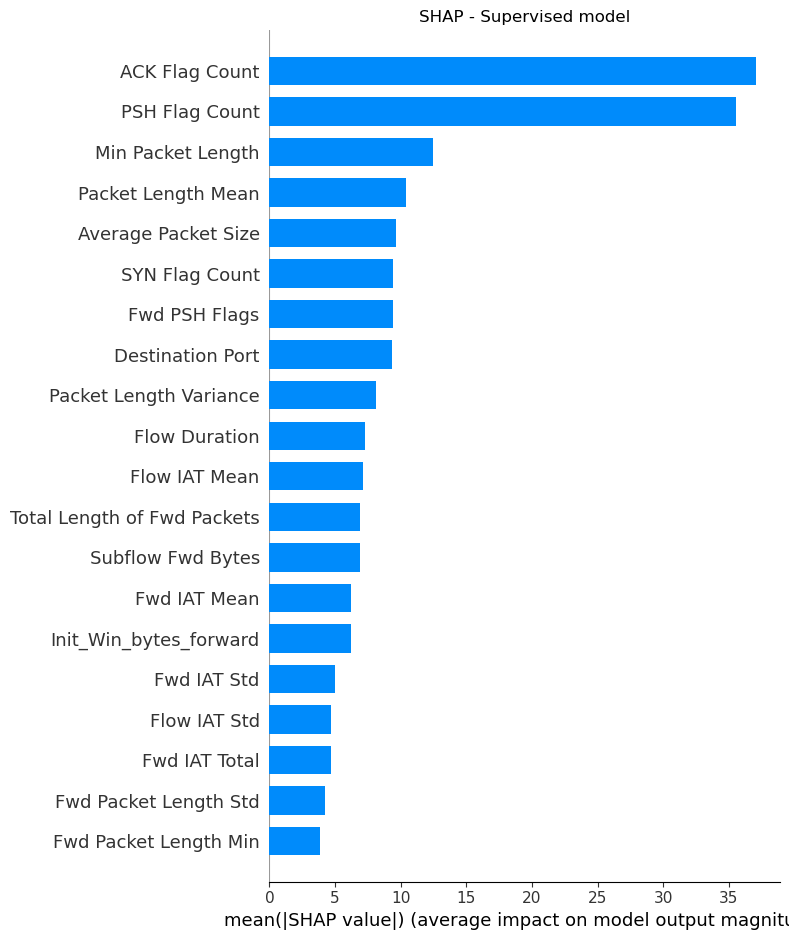

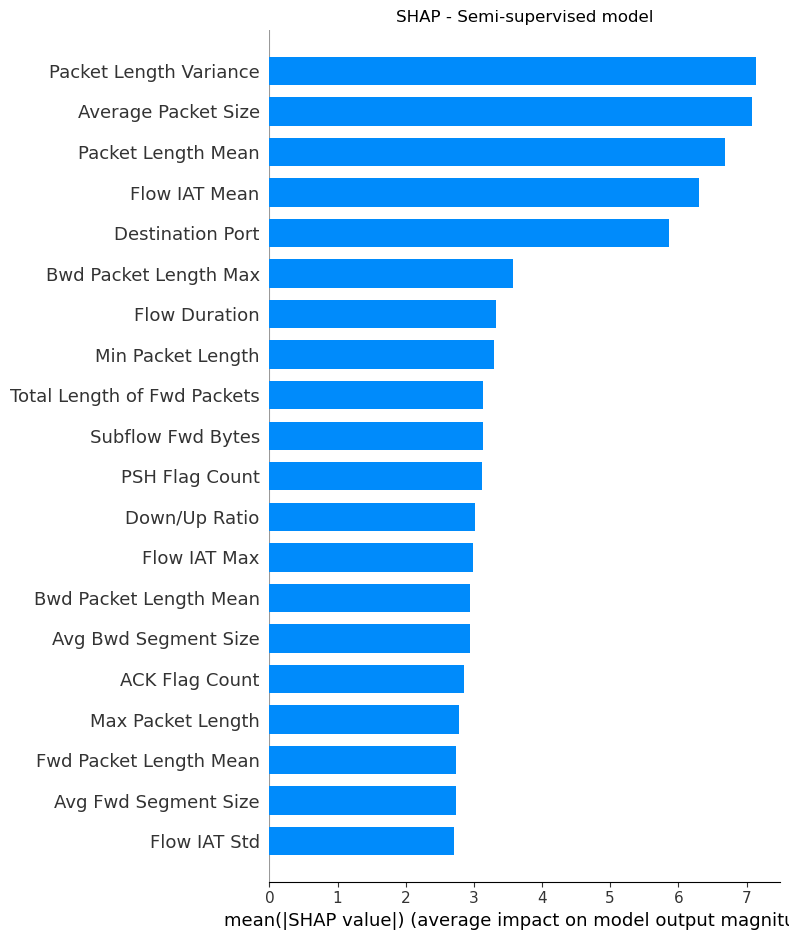

In [23]:
# Step 2: Generate SHAP explanations for both models

# A reproducible sample of 150 test observations is selected
# for model explanation.

# SHAP values estimate how strongly each feature contributes
# to the model's predictions.

# Summary plots show the average absolute SHAP importance
# of the features for each model.
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(X_test_scaled), size=150, replace=False)
X_explain_sample = X_test_scaled[sample_idx]

explainer_sup = shap.Explainer(lr_full, X_train_scaled[:100], feature_names=feature_names)
shap_values_sup = explainer_sup(X_explain_sample)

explainer_semi = shap.Explainer(pl_5, X_train_scaled[:100], feature_names=feature_names)
shap_values_semi = explainer_semi(X_explain_sample)

shap.summary_plot(shap_values_sup, X_explain_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP - Supervised model")
plt.tight_layout()
plt.savefig("shap_supervised.png", dpi=150)
plt.show()

shap.summary_plot(shap_values_semi, X_explain_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP - Semi-supervised model")
plt.tight_layout()
plt.savefig("shap_semi.png", dpi=150)
plt.show()


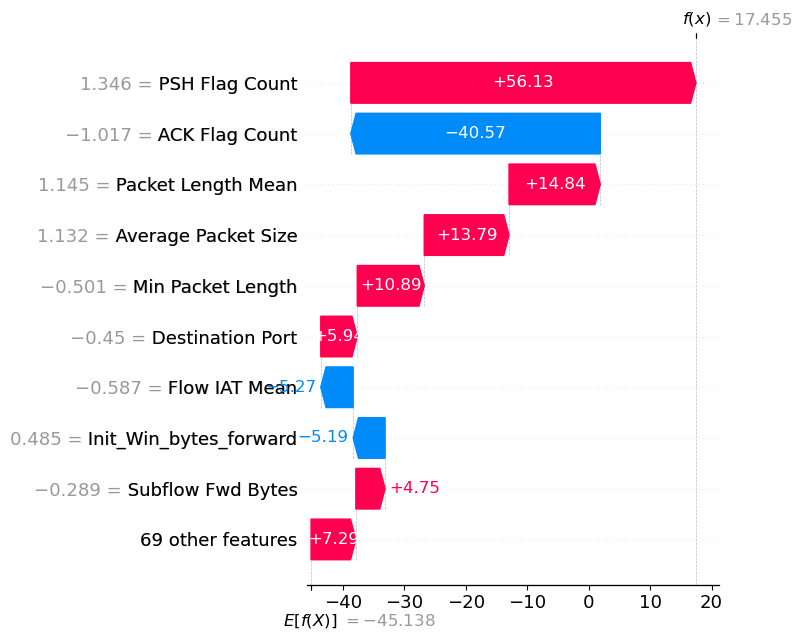

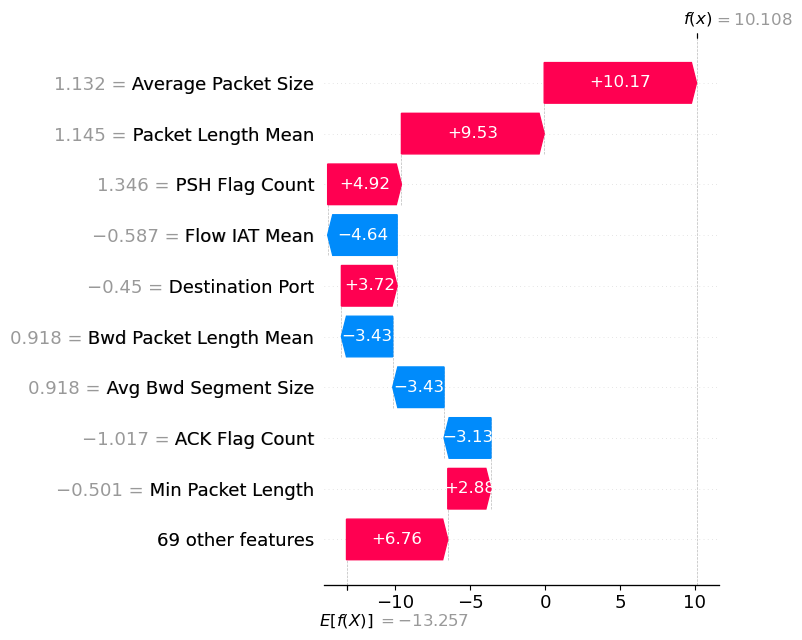

In [24]:
# Step 2: Generate SHAP waterfall plots

# Waterfall plots explain the contribution of individual features
# to a single prediction for each model.

shap.plots.waterfall(shap_values_sup[0], show=False)
plt.tight_layout()
plt.savefig("shap_supervised_waterfall.png", dpi=150)
plt.show()

shap.plots.waterfall(shap_values_semi[0], show=False)
plt.tight_layout()
plt.savefig("shap_semi_waterfall.png", dpi=150)
plt.show()

In [25]:

#Step 3: Generate LIME explanations for both models

# LIME creates a local explanation by approximating the model
# around an individual test observation.

# The five most influential features for the selected observation
# are displayed for each model.

lime_explainer = LimeTabularExplainer(
    X_train_scaled, feature_names=feature_names,
    class_names=["Normal", "Attack"], mode="classification", random_state=SEED)

print("LIME - Supervised model, sample 0:")
exp = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)
print(exp.as_list())

print("\nLIME - Semi-supervised model, sample 0:")
exp2 = lime_explainer.explain_instance(X_test_scaled[0], pl_5.predict_proba, num_features=5)
print(exp2.as_list())

LIME - Supervised model, sample 0:
[('PSH Flag Count <= -0.74', -0.23512111067685265), ('-1.02 < ACK Flag Count <= 0.98', 0.1501712572006393), ('Subflow Fwd Bytes > -0.28', -0.13576989073159207), ('Total Length of Fwd Packets > -0.28', -0.12729439477953694), ('Subflow Bwd Packets > 0.02', -0.11826532914094709)]

LIME - Semi-supervised model, sample 0:
[('Packet Length Variance > 0.42', 0.16894213844495468), ('Subflow Bwd Packets > 0.02', -0.1480280142355756), ('Total Backward Packets > 0.02', -0.11654274296610924), ('Bwd Header Length > 0.03', -0.11505801232869975), ('Destination Port > -0.45', -0.10132225948441376)]


In [26]:
#Step 3/4: Check LIME explanation stability

# The same test observation is explained twice using LIME.
# Comparing the two explanations helps assess how consistent
# the local explanation is for the same prediction.

run1 = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)
run2 = lime_explainer.explain_instance(X_test_scaled[0], lr_full.predict_proba, num_features=5)

print("LIME run 1:", run1.as_list())
print("LIME run 2:", run2.as_list())
print("\nIf these two lists look different, LIME is a bit unstable for this sample.")

LIME run 1: [('PSH Flag Count <= -0.74', -0.20968426408062207), ('Total Length of Fwd Packets > -0.28', -0.15272747256776498), ('-1.02 < ACK Flag Count <= 0.98', 0.1275728172894975), ('Bwd Header Length > 0.03', -0.12200931928888815), ('Total Backward Packets > 0.02', -0.1142382541489774)]
LIME run 2: [('PSH Flag Count <= -0.74', -0.21256510039763804), ('-1.02 < ACK Flag Count <= 0.98', 0.14769937926333146), ('Subflow Fwd Bytes > -0.28', -0.1370096004552932), ('Total Length of Fwd Packets > -0.28', -0.13078895952008876), ('Bwd Header Length > 0.03', -0.11803256394967941)]

If these two lists look different, LIME is a bit unstable for this sample.


In [ ]:
# Step 5: Identify the two most important features for each model

# Mean absolute SHAP values are calculated across the explanation
# sample and used to rank features by their overall importance.

# The two features with the highest mean absolute SHAP values
# are selected for each model.

importance_sup = pd.Series(
    np.abs(shap_values_sup.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

importance_semi = pd.Series(
    np.abs(shap_values_semi.values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

top2_sup = importance_sup.index[:2].tolist()
top2_semi = importance_semi.index[:2].tolist()

print("Top-2 features (supervised):     ", top2_sup)
print("Top-2 features (semi-supervised):", top2_semi)

Top-2 features (supervised):      ['ACK Flag Count', 'PSH Flag Count']
Top-2 features (semi-supervised): ['Packet Length Variance', 'Average Packet Size']
